# Equity champions — feature importance (train-only, clean split)

Champions from `selection_table.csv` — purged inner k-fold + 1SE, global cut **2021-10-06**.
All importance analysis uses **train data only** (post-split). The held-out 30% (post-2021-10-20) is **sealed**.

| Instrument | Group | Champion | AUC | Lower CI | Signal |
|------------|-------|----------|-----|----------|--------|
| es1s | es1s | RF | 0.516±0.113 | 0.40 | NO |
| nq1s | nq1s | XGB | 0.689±0.073 | 0.62 | YES |
| fesx1s | fesx1s | Logistic | 0.579±0.060 | 0.52 | YES |

> **es1s** carries no confirmed signal (lower CI < 0.50). Its importance analysis is included for contrast only — results reflect model noise rather than exploitable structure.


---
## Analysis pipeline

The same five-step sequence is applied to each instrument. All computations run on **train data only**;
the sealed 30% test set is never read here and no model is evaluated OOS.

### Step 1 — Feature clustering
Continuous features (excluding hand-assigned groups) are clustered by **Spearman distance** √(1−|ρ|)
with **Ward linkage**. The number of clusters K is chosen by silhouette score over K ∈ [2, 25].
Four groups are hand-assigned by prefix: `f4_` → F4_latent, `f5_` → F5_signal, `f8_` → F8_calendar,
`inst_` → F_instrument (pooled models only). These bypass correlation clustering.

### Step 2 — Cluster-level importance
Three importance signals per cluster, evaluated within **CPCV** (n_groups=6, k=2, embargo=1 %):

- **Clustered MDA** (headline): jointly permute all cluster members with one shared row permutation;
  N=10 repeats averaged; score AUC drop on target instrument's CPCV test slice.
  For pooled models the test slice is filtered to the target instrument before scoring.
- **Tree models** — MDI (train; sum feature_importances_ within cluster) and Group SHAP
  (TreeSHAP, tree_path_dependent, OOS slice).
- **Logistic model** — cluster |coef| sum (sum of |standardised elastic-net coefficients|
  per cluster). MDA permutes the **scaled** data (scaler fitted on outer-train fold).

A cluster is **significant** when its mean MDA drop > 1σ (cross-CPCV std).
**Rank agreement** is assessed via Kendall τ across cluster MDA / MDI / SHAP rankings
(or MDA / Coef for logistic); |τ| > 0.4 is treated as agreement.

### Step 3 — Within-cluster breakdown (top 3 clusters)
For the top 3 clusters by MDA (preferring significant clusters), individual members are ranked
by mean |SHAP| (tree) or mean |coef| (logistic). Single-feature permutation is intentionally
**not used** within a cluster — correlated members would inflate individual scores.

### Step 4 — PCA within top clusters
**PCA** (up to 3 PCs, standardised inputs) on the cluster's train submatrix.
PC1 variance interpretation tier: ≥65 % = single latent dimension; 40–65 % = dominant direction;
<40 % = genuinely multi-dimensional. Loadings reveal which members drive each component.

### Step 5 — Global per-feature view
**Tree**: mean |SHAP| per feature (averaged across CPCV paths), coloured by sign (red = positive,
blue = negative predictive direction). Also reports per-feature MDI.
**Logistic**: mean |standardised coefficient| per feature, coloured by sign.
SHAP direction reflects **model direction**, not necessarily profitable direction — the model may
learn to trade against a feature.


In [1]:
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/importance')

def show(path, width=1100):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))
    else:
        print(f'[missing] {p}')

def load(path):
    p = Path(path)
    if p.exists():
        return pd.read_csv(p)
    print(f'[missing] {p}')
    return pd.DataFrame()

def cluster_summary(inst):
    mem = load(BASE / inst / 'cluster_membership.csv')
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mem.empty or mda.empty:
        return pd.DataFrame()
    grp = (
        mem.groupby('cluster')
        .agg(
            n_members=('feature', 'count'),
            dominant_pfx=('f_prefix', lambda x: x.value_counts().index[0]),
            purity=('f_prefix', lambda x: round(x.value_counts().iloc[0] / len(x), 2)),
        )
        .reset_index()
    )
    mda_sub = mda[['cluster', 'mean_drop', 'std_drop', 'significant']].copy()
    return grp.merge(mda_sub, on='cluster', how='left').sort_values('mean_drop', ascending=False)

print('Setup complete. Artifact root:', BASE.resolve())


Setup complete. Artifact root: /Users/harrybrowne/Downloads/Imperial Work/SystematicTrading/stml/src/stml/new_work/outputs/importance


---
## ES1S — champion: `es1s` / RF

**CPCV:** 15 paths · AUC 0.548 ± 0.112 (held-out CPCV) · **NO SIGNAL** (lower CI 0.40)

**Significant clusters:** F5\_signal only.

> **Interpretation caveat:** es1s has no confirmed signal. The dominant cluster (F5_signal, MDA 0.083)
> reflects the model's reliance on internal signal-quality features rather than external market
> predictors. Weak MDA–MDI (τ=0.18) and MDA–SHAP (τ=0.24) agreement with strong MDI–SHAP agreement
> (τ=0.91) suggests the tree's internal metrics are coherent but MDA identifies different,
> noisier structure. Results are included for contrast only.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
15,F5_signal,5,f5_,100%,0.0827,0.0343,True
4,C14_f11,7,f11_,29%,0.0185,0.0550,False
6,C2_f2,16,f2_,44%,0.0122,0.0226,False
7,C3_f11_lowfreq_macro,2,f11_,100%,0.0003,0.0035,False
9,C5_f7,3,f7_,100%,-0.0007,0.0146,False
16,F8_calendar,4,f8_,100%,-0.0009,0.0031,False
0,C10_f1,14,f1_,79%,-0.0026,0.0137,False
8,C4_f11,4,f11_,50%,-0.0027,0.0122,False
13,C9_f11,7,f11_,43%,-0.0029,0.0075,False
11,C7_f11,8,f11_,38%,-0.0032,0.0128,False


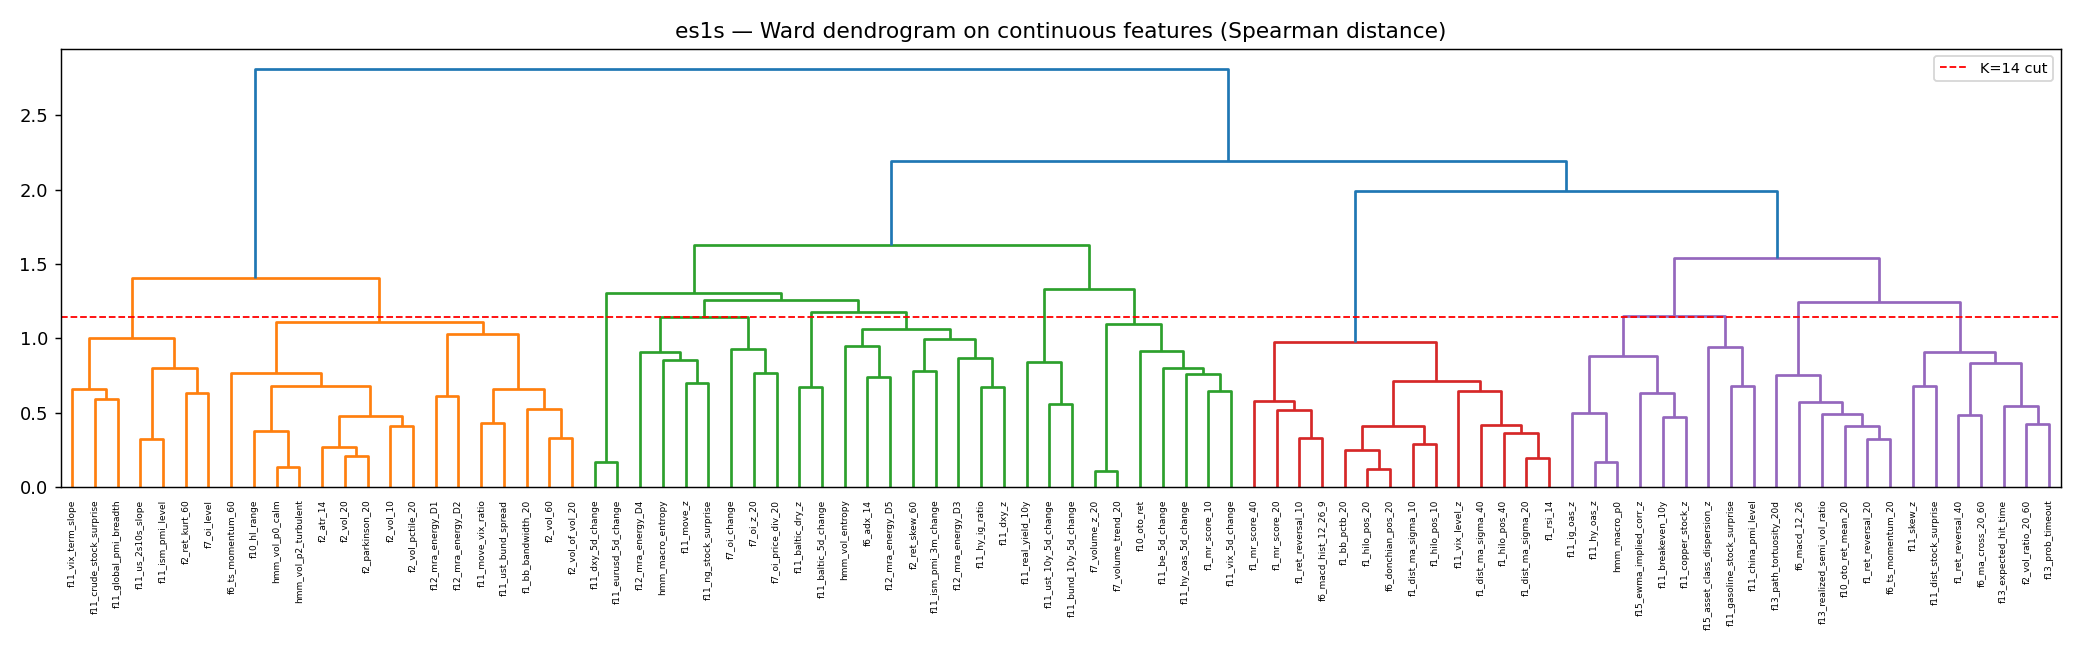

In [2]:
cs = cluster_summary('es1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.10)
    .set_caption('es1s — cluster summary (K=14 corr + 3 hand-assigned = 17 groups)')
)
show(BASE / 'es1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ, light = inconclusive). Cross-check with MDI and SHAP.
Rank agreement assessed via Kendall τ; |τ| > 0.4 = agree.


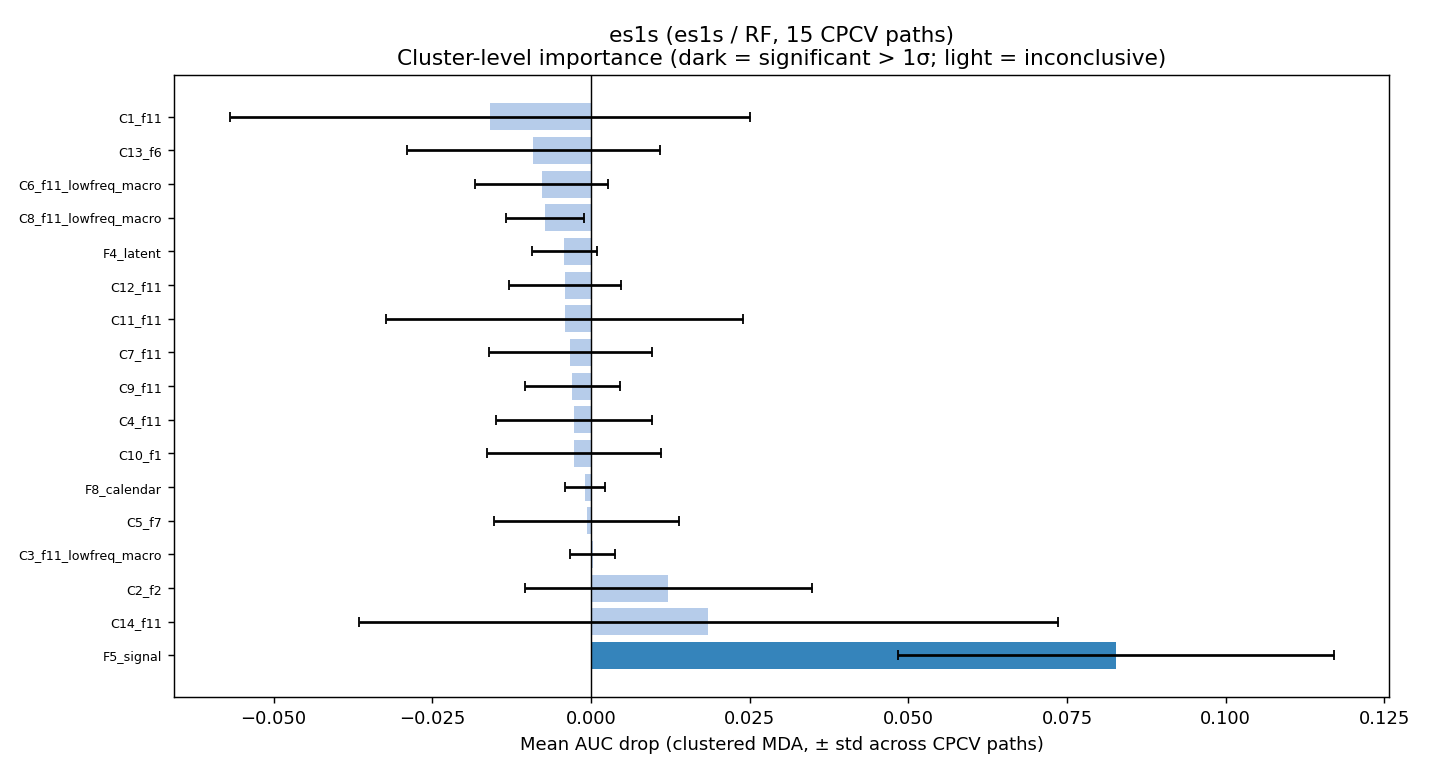

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,F5_signal,0.0827,1,0.1241,3,0.0370,2,True
1,C14_f11,0.0185,2,0.1318,2,0.0356,3,False
2,C2_f2,0.0122,3,0.1560,1,0.0462,1,False
3,C3_f11_lowfreq_macro,0.0003,4,0.0087,17,0.0016,17,False
4,C5_f7,-0.0007,5,0.0324,12,0.0094,10,False
5,F8_calendar,-0.0009,6,0.0098,16,0.0043,14,False
6,C10_f1,-0.0026,7,0.0681,6,0.0180,6,False
7,C4_f11,-0.0027,8,0.0554,8,0.0134,8,False
8,C9_f11,-0.0029,9,0.0401,10,0.0082,12,False
9,C7_f11,-0.0032,10,0.0656,7,0.0150,7,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.18,False
1,MDA-SHAP,0.24,False
2,MDI-SHAP,0.91,True


In [3]:
show(BASE / 'es1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'es1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'es1s' / 'rank_agreement.csv')
if not cc.empty:
    display(
        cc.style
        .format({'mda_mean': '{:.4f}', 'mdi_sum': '{:.4f}', 'shap_sum': '{:.4f}'})
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.10)
        .set_caption('es1s — cluster cross-check (MDA · MDI · SHAP ranks)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP| (tree_path_dependent, OOS). PCA on train submatrix.

**F5_signal** (signal-quality features) is the only significant cluster — meaning the RF
gains primarily by learning the regime/participation/trailing-run context of its own signals,
not from external market predictors.


,feature,mean_shap_mag,pc1_loading
0,f5_signal,0.0058,0.378
1,f5_trailing_run_length,0.0244,0.490
2,f5_participation_20,0.0015,0.499
3,f5_long_bias_20,0.0035,0.535
4,f5_sign_agree_mr,0.0018,-0.285


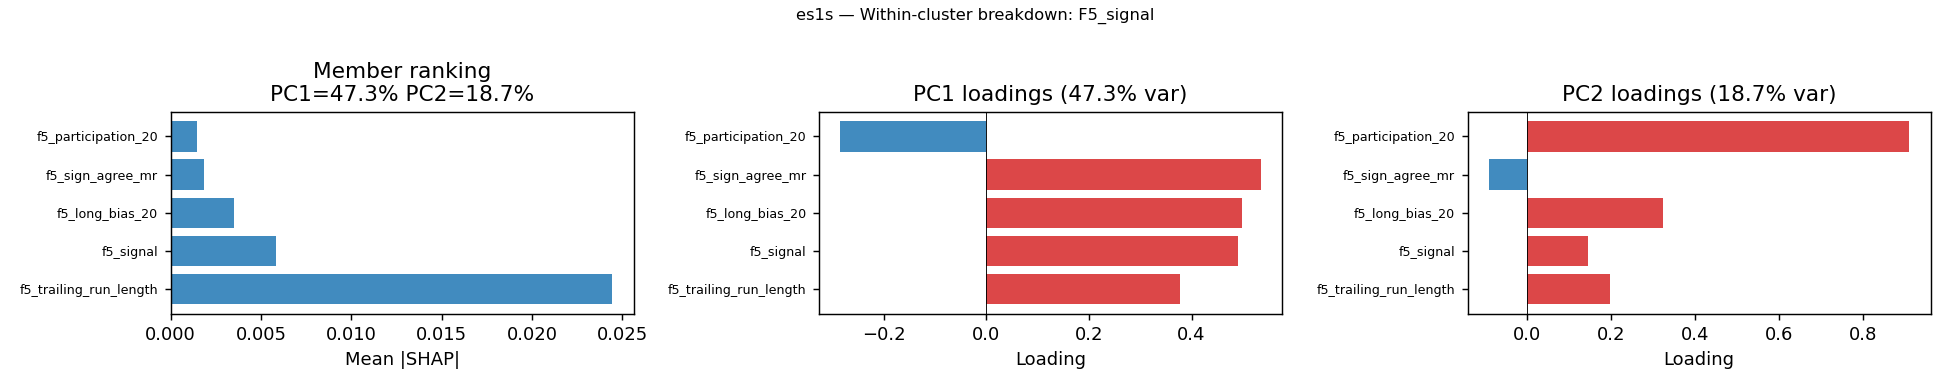

In [4]:
wc = load(BASE / 'es1s' / 'within_cluster_F5_signal.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    display(
        wc[['feature', 'mean_shap_mag', 'pc1_loading']].style
        .format({'mean_shap_mag': '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=['mean_shap_mag'], cmap='Blues')
        .set_caption(f'es1s | F5_signal — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_F5_signal.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f1_ret_reversal_40,0.0027,0.395
1,f2_vol_ratio_20_60,0.0057,0.432
2,f6_ma_cross_20_60,0.0037,-0.362
3,f11_skew_z,0.0081,-0.338
4,f11_dist_stock_surprise,0.0117,-0.252
5,f13_expected_hit_time,0.0009,0.392
6,f13_prob_timeout,0.0029,0.440


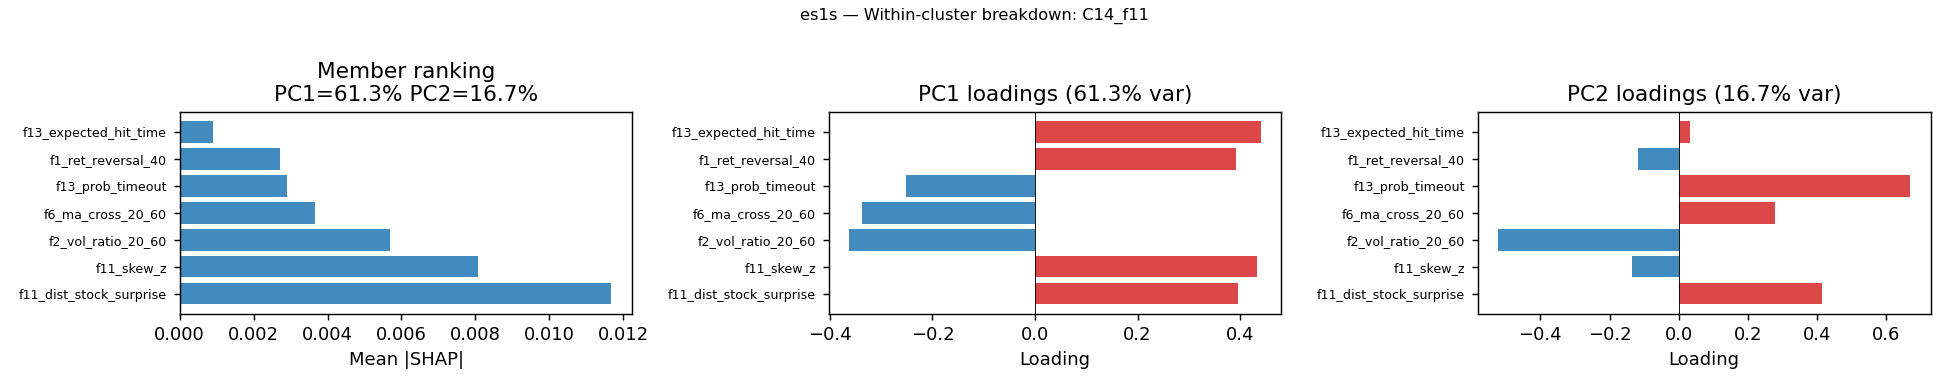

In [5]:
wc = load(BASE / 'es1s' / 'within_cluster_C14_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    display(
        wc[['feature', 'mean_shap_mag', 'pc1_loading']].style
        .format({'mean_shap_mag': '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=['mean_shap_mag'], cmap='Blues')
        .set_caption(f'es1s | C14_f11 — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C14_f11.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f1_bb_bandwidth_20,0.0049,0.274
1,f2_vol_10,0.0027,0.277
2,f2_vol_20,0.0007,0.291
3,f2_vol_60,0.0053,0.268
4,f2_vol_pctile_20,0.0026,0.255
5,f2_vol_of_vol_20,0.0021,0.263
6,f2_parkinson_20,0.0013,0.293
7,f2_atr_14,0.0033,0.303
8,f6_ts_momentum_60,0.0027,-0.258
9,f10_hl_range,0.0025,0.246


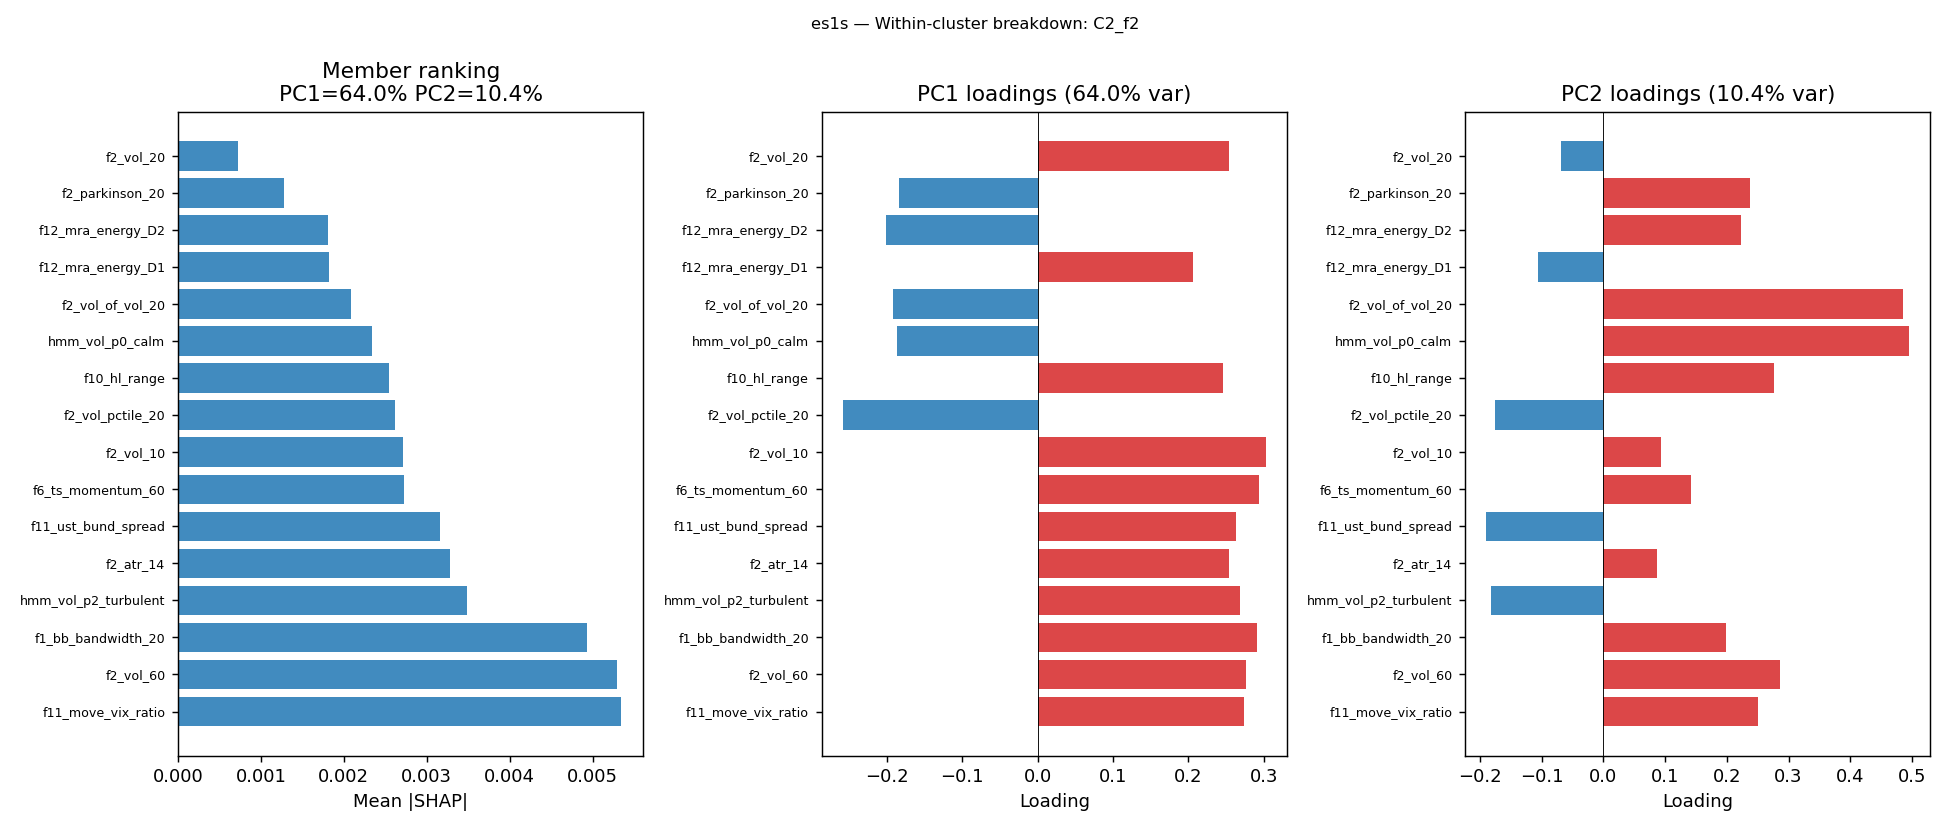

In [6]:
wc = load(BASE / 'es1s' / 'within_cluster_C2_f2.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    display(
        wc[['feature', 'mean_shap_mag', 'pc1_loading']].style
        .format({'mean_shap_mag': '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=['mean_shap_mag'], cmap='Blues')
        .set_caption(f'es1s | C2_f2 — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'es1s' / 'within_cluster_C2_f2.png', width=950)


### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths. Red = positive predictive direction,
blue = negative. Note: results for es1s reflect model noise rather than confirmed signal structure.


,feature,shap_magnitude,shap_signed,mdi
0,f5_trailing_run_length,0.0244,0.0021,0.0819
1,f11_dist_stock_surprise,0.0117,0.0020,0.0439
2,f11_skew_z,0.0081,0.0024,0.0283
3,f7_oi_z_20,0.0079,0.0009,0.0250
4,f11_gasoline_stock_surprise,0.0079,0.0024,0.0321
5,f11_breakeven_10y,0.0063,0.0000,0.0295
6,f11_ng_stock_surprise,0.0060,0.0011,0.0229
7,f5_signal,0.0058,0.0014,0.0186
8,f2_vol_ratio_20_60,0.0057,0.0030,0.0198
9,f11_move_vix_ratio,0.0053,-0.0016,0.0150


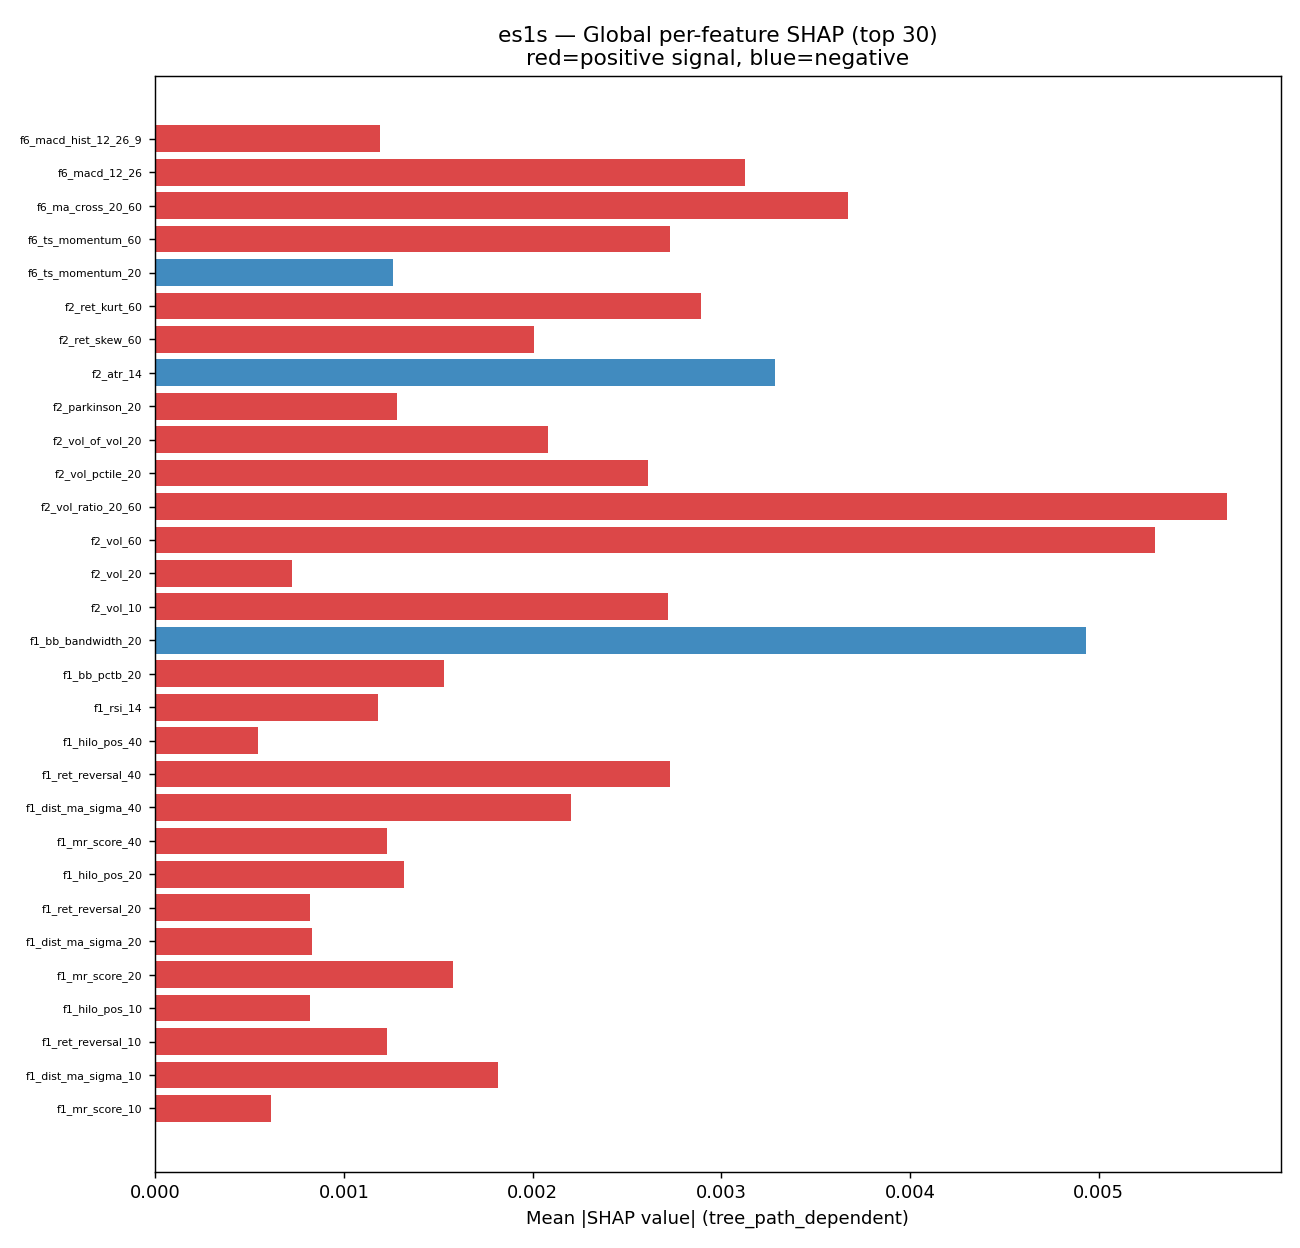

In [7]:
gs = load(BASE / 'es1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('es1s — top 25 features by mean|SHAP| (NO SIGNAL — illustrative only)')
    )
show(BASE / 'es1s' / 'global_shap_chart.png', width=1000)


---
## NQ1S — champion: `nq1s` / XGB

**CPCV:** 15 paths · AUC 0.720 ± 0.073 · **SIGNAL** (lower CI 0.62)

**Significant clusters:** F5\_signal (MDA 0.174 ± 0.074), C4\_f11 (MDA 0.063 ± 0.050).

> NQ1S is the strongest equity champion. Two clusters clear the 1σ bar. The dominant driver
> `f11_dist_stock_surprise` (distillate stock surprise) in C4_f11 is striking for an equity index —
> it likely captures risk-off macro regime via energy inventory shocks. MDA–SHAP agree (τ=0.49),
> indicating the headline importance ranking is robust.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.1744,0.0736,True
9,C4_f11,5,f11_,40%,0.0627,0.0499,True
13,C8_f11,9,f11_,78%,0.0124,0.0274,False
11,C6_f11,6,f11_,83%,0.0095,0.0195,False
1,C11_f11,7,f11_,57%,0.0063,0.0149,False
2,C12_f11_lowfreq_macro,2,f11_,100%,0.0057,0.0115,False
0,C10_f7,2,f7_,100%,0.0015,0.0050,False
8,C3_f6,6,f6_,33%,0.0012,0.0041,False
14,C9_f11_lowfreq_macro,3,f11_,100%,0.0005,0.0055,False
12,C7_f12,8,f12_,38%,-0.0000,0.0037,False


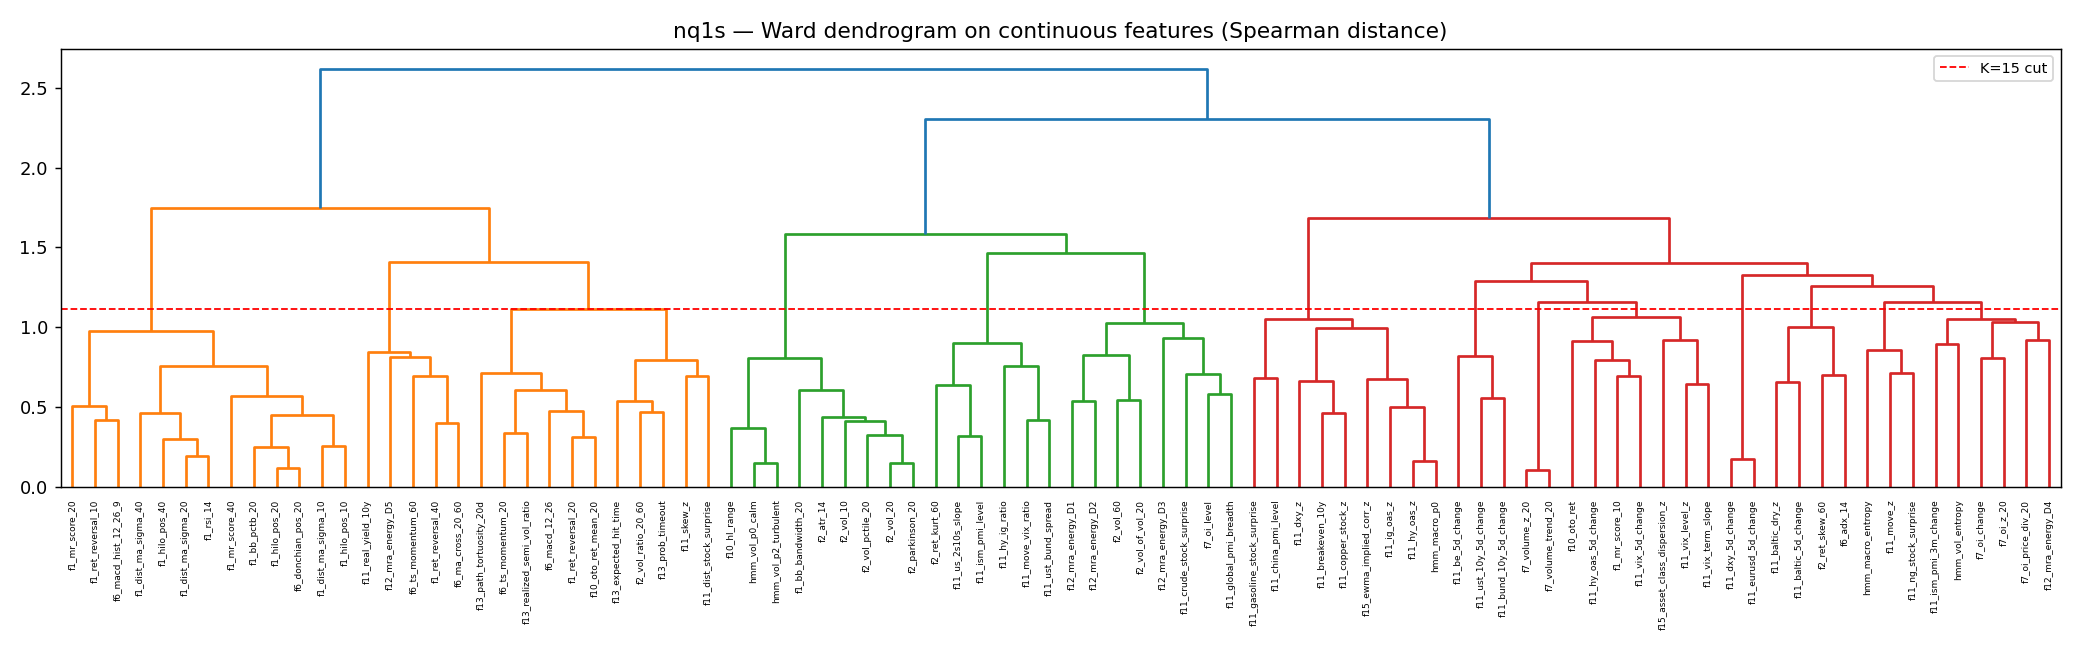

In [8]:
cs = cluster_summary('nq1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.20)
    .set_caption('nq1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'nq1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ). Cross-check with MDI and SHAP.


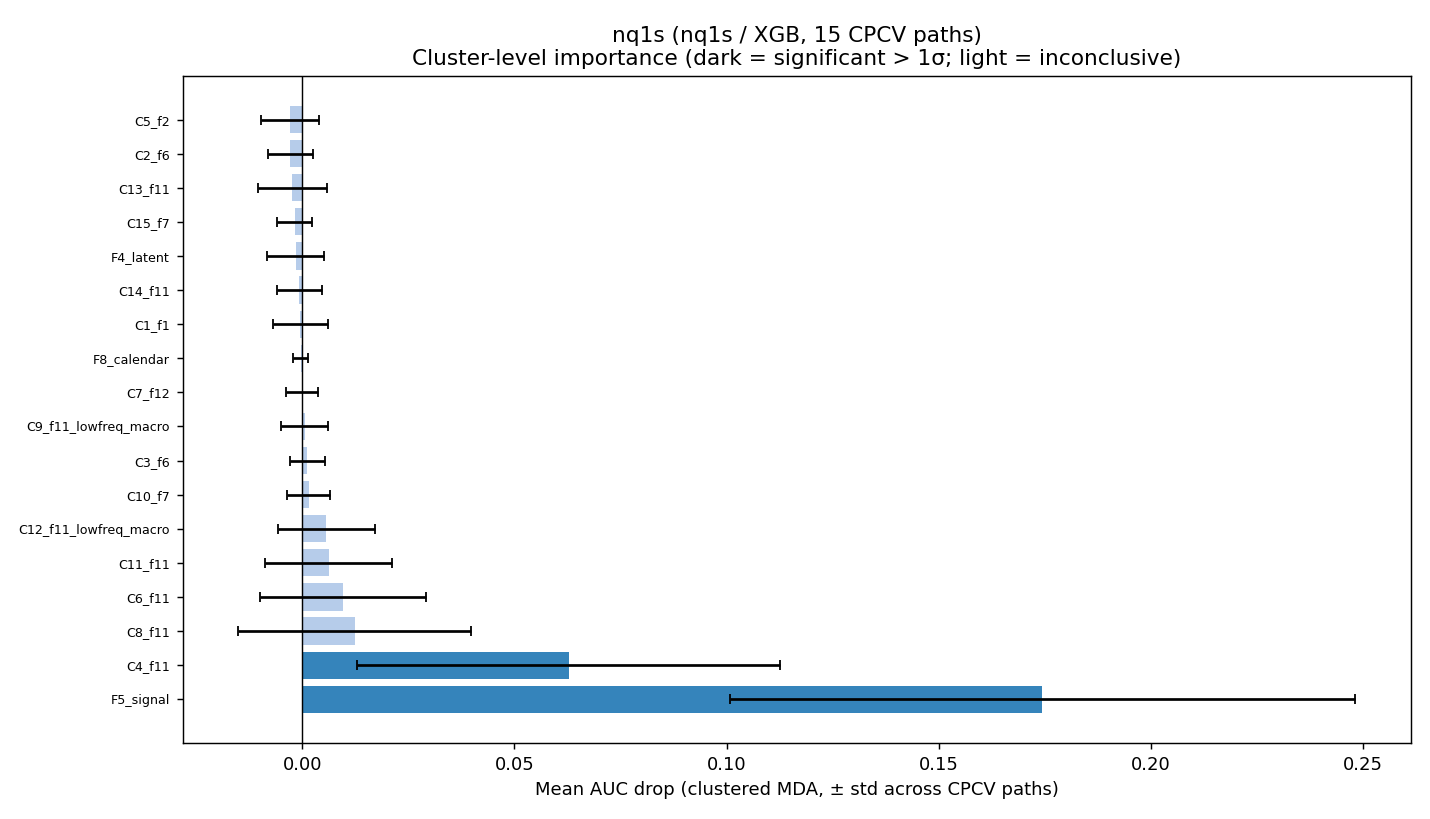

,cluster,mda_mean,mda_rank,mdi_sum,mdi_rank,shap_sum,shap_rank,significant
0,F5_signal,0.1744,1,0.0889,3,0.3044,1,True
1,C4_f11,0.0627,2,0.0743,5,0.0780,3,True
2,C8_f11,0.0124,3,0.1237,1,0.0969,2,False
3,C6_f11,0.0095,4,0.0777,4,0.0622,4,False
4,C11_f11,0.0063,5,0.0651,7,0.0606,5,False
5,C12_f11_lowfreq_macro,0.0057,6,0.0339,14,0.0283,7,False
6,C10_f7,0.0015,7,0.0312,15,0.0105,15,False
7,C3_f6,0.0012,8,0.0446,11,0.0076,17,False
8,C9_f11_lowfreq_macro,0.0005,9,0.0354,13,0.0213,9,False
9,C7_f12,-0.0000,10,0.0625,8,0.0201,10,False



Kendall τ rank agreement:


,method_pair,kendall_tau,agree
0,MDA-MDI,0.24,False
1,MDA-SHAP,0.49,True
2,MDI-SHAP,0.59,True


In [9]:
show(BASE / 'nq1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'nq1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'nq1s' / 'rank_agreement.csv')
if not cc.empty:
    display(
        cc.style
        .format({'mda_mean': '{:.4f}', 'mdi_sum': '{:.4f}', 'shap_sum': '{:.4f}'})
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.20)
        .set_caption('nq1s — cluster cross-check (MDA · MDI · SHAP ranks)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement:')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |SHAP|. PCA on train submatrix.

**F5_signal** PC1 explains 38% of variance — genuinely multi-dimensional (4 members span diverse
signal-quality axes). `f5_signal` dominates by SHAP (0.298, >> others).

**C4_f11** (4 mixed-f-prefix members): `f11_dist_stock_surprise` dominates (SHAP 0.061),
PC1 explains 67% suggesting one latent macro risk dimension.


,feature,mean_shap_mag,pc1_loading
0,f5_signal,0.2978,0.475
1,f5_trailing_run_length,0.0009,0.534
2,f5_participation_20,0.0003,0.247
3,f5_long_bias_20,0.0038,0.582
4,f5_sign_agree_mr,0.0015,-0.299


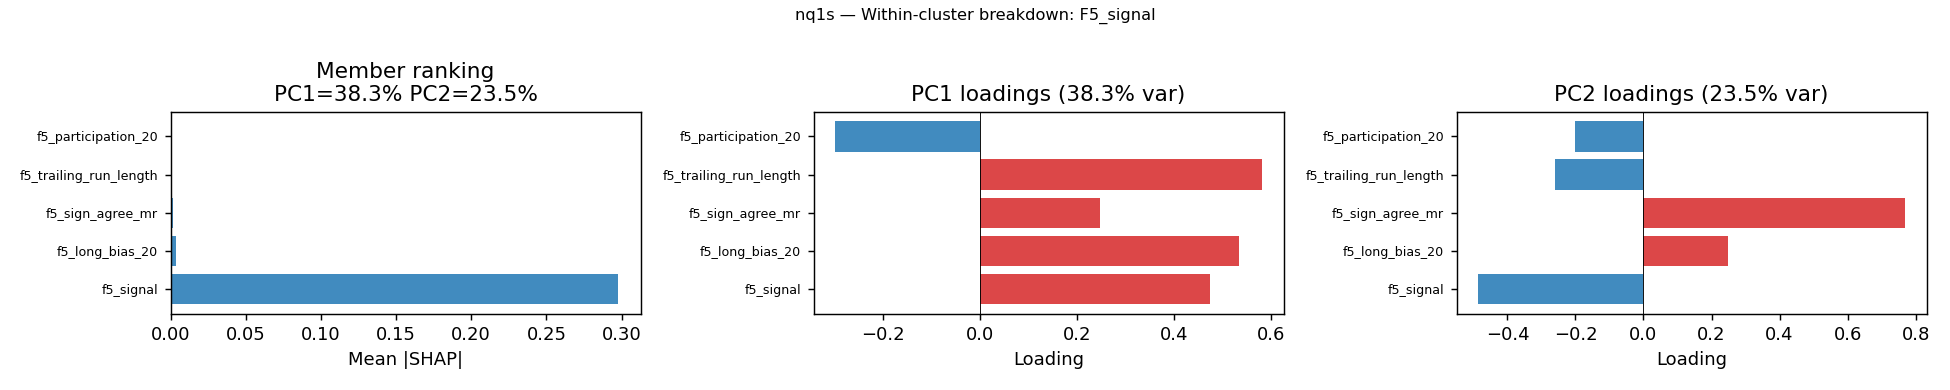

In [10]:
wc = load(BASE / 'nq1s' / 'within_cluster_F5_signal.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    display(
        wc[['feature', 'mean_shap_mag', 'pc1_loading']].style
        .format({'mean_shap_mag': '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=['mean_shap_mag'], cmap='Blues')
        .set_caption(f'nq1s | F5_signal — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_F5_signal.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f2_vol_ratio_20_60,0.0090,0.484
1,f11_skew_z,0.0035,-0.411
2,f11_dist_stock_surprise,0.0609,-0.370
3,f13_expected_hit_time,0.0005,0.460
4,f13_prob_timeout,0.0041,0.498


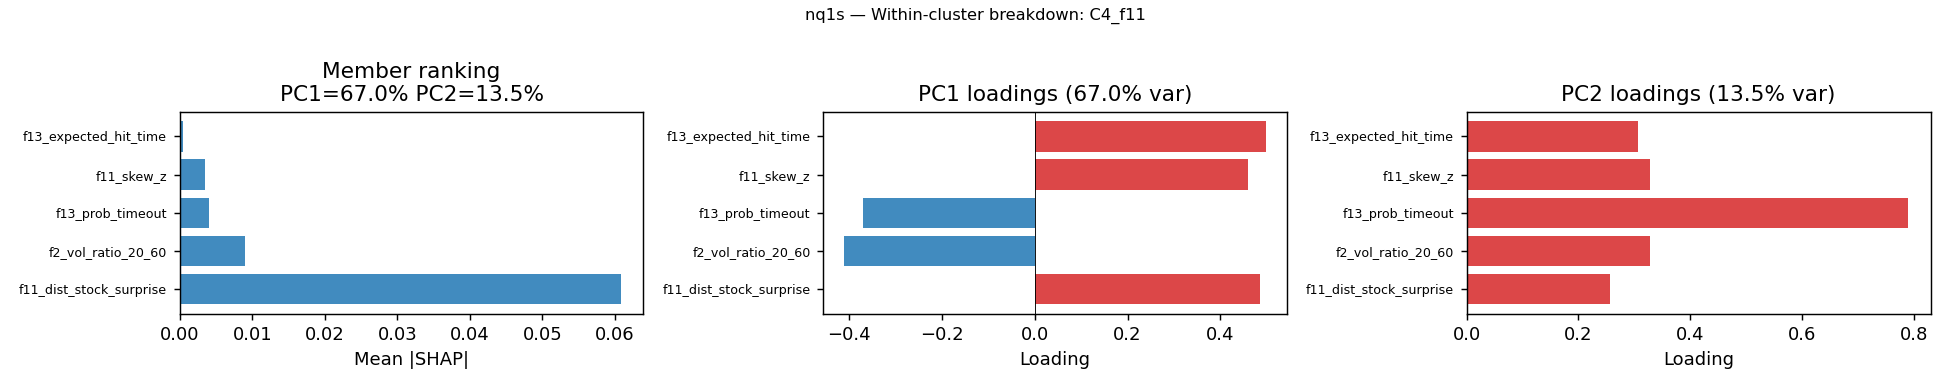

In [11]:
wc = load(BASE / 'nq1s' / 'within_cluster_C4_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    display(
        wc[['feature', 'mean_shap_mag', 'pc1_loading']].style
        .format({'mean_shap_mag': '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=['mean_shap_mag'], cmap='Blues')
        .set_caption(f'nq1s | C4_f11 — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C4_f11.png', width=950)


,feature,mean_shap_mag,pc1_loading
0,f11_breakeven_10y,0.0132,-0.363
1,f11_hy_oas_z,0.0018,0.396
2,f11_ig_oas_z,0.0011,0.393
3,f11_dxy_z,0.0085,0.247
4,f11_gasoline_stock_surprise,0.0254,-0.155
5,f11_copper_stock_z,0.0390,-0.366
6,f11_china_pmi_level,0.0016,-0.298
7,f15_ewma_implied_corr_z,0.0029,0.345
8,hmm_macro_p0,0.0035,-0.361


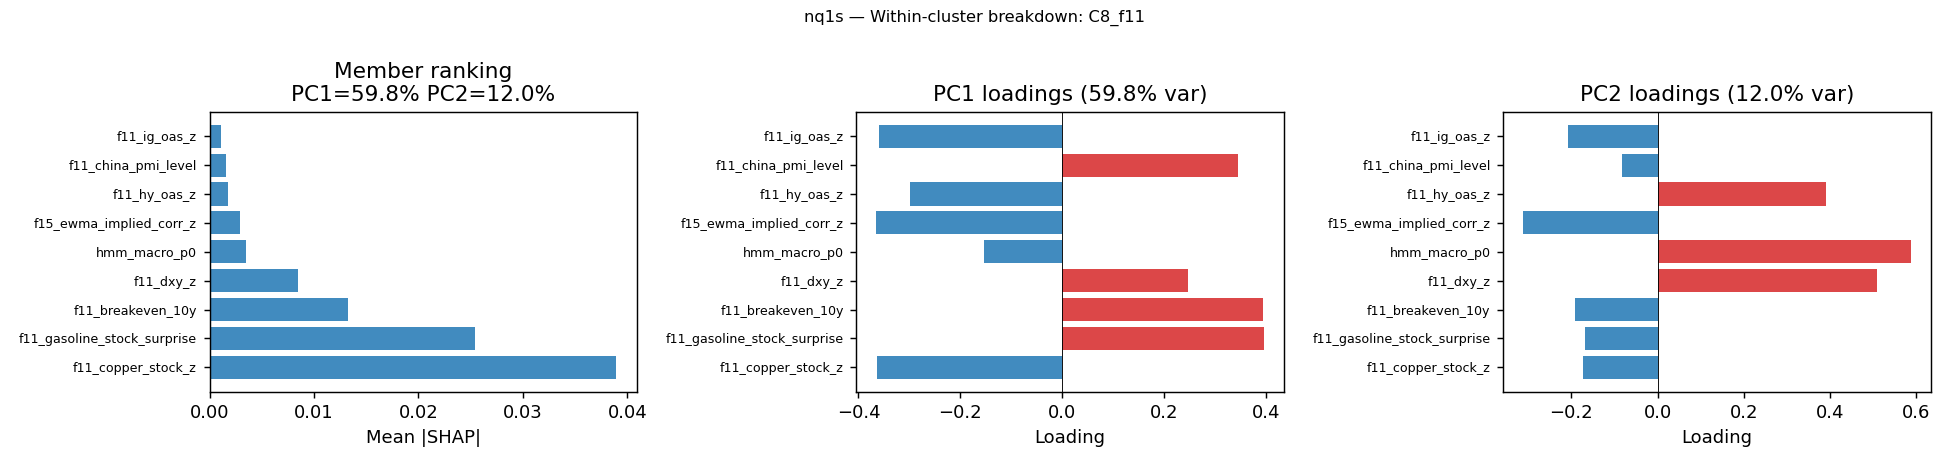

In [12]:
wc = load(BASE / 'nq1s' / 'within_cluster_C8_f11.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    display(
        wc[['feature', 'mean_shap_mag', 'pc1_loading']].style
        .format({'mean_shap_mag': '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=['mean_shap_mag'], cmap='Blues')
        .set_caption(f'nq1s | C8_f11 — SHAP ranking + PC1 loadings  ({label})')
    )
show(BASE / 'nq1s' / 'within_cluster_C8_f11.png', width=950)


### Step 5 · Global per-feature SHAP

Mean |SHAP| per feature, averaged across 15 CPCV paths on nq1s. Red = positive, blue = negative.


,feature,shap_magnitude,shap_signed,mdi
0,f5_signal,0.2978,0.0820,0.0636
1,f11_dist_stock_surprise,0.0609,-0.0118,0.0365
2,f11_copper_stock_z,0.0390,0.0111,0.0252
3,f11_vix_5d_change,0.0333,0.0099,0.0256
4,f11_gasoline_stock_surprise,0.0254,-0.0007,0.0216
5,f11_move_vix_ratio,0.0246,-0.0084,0.0204
6,f11_dxy_5d_change,0.0230,-0.0025,0.0192
7,f11_be_5d_change,0.0174,0.0071,0.0201
8,f11_hy_ig_ratio,0.0151,0.0020,0.0128
9,f11_breakeven_10y,0.0132,0.0018,0.0185


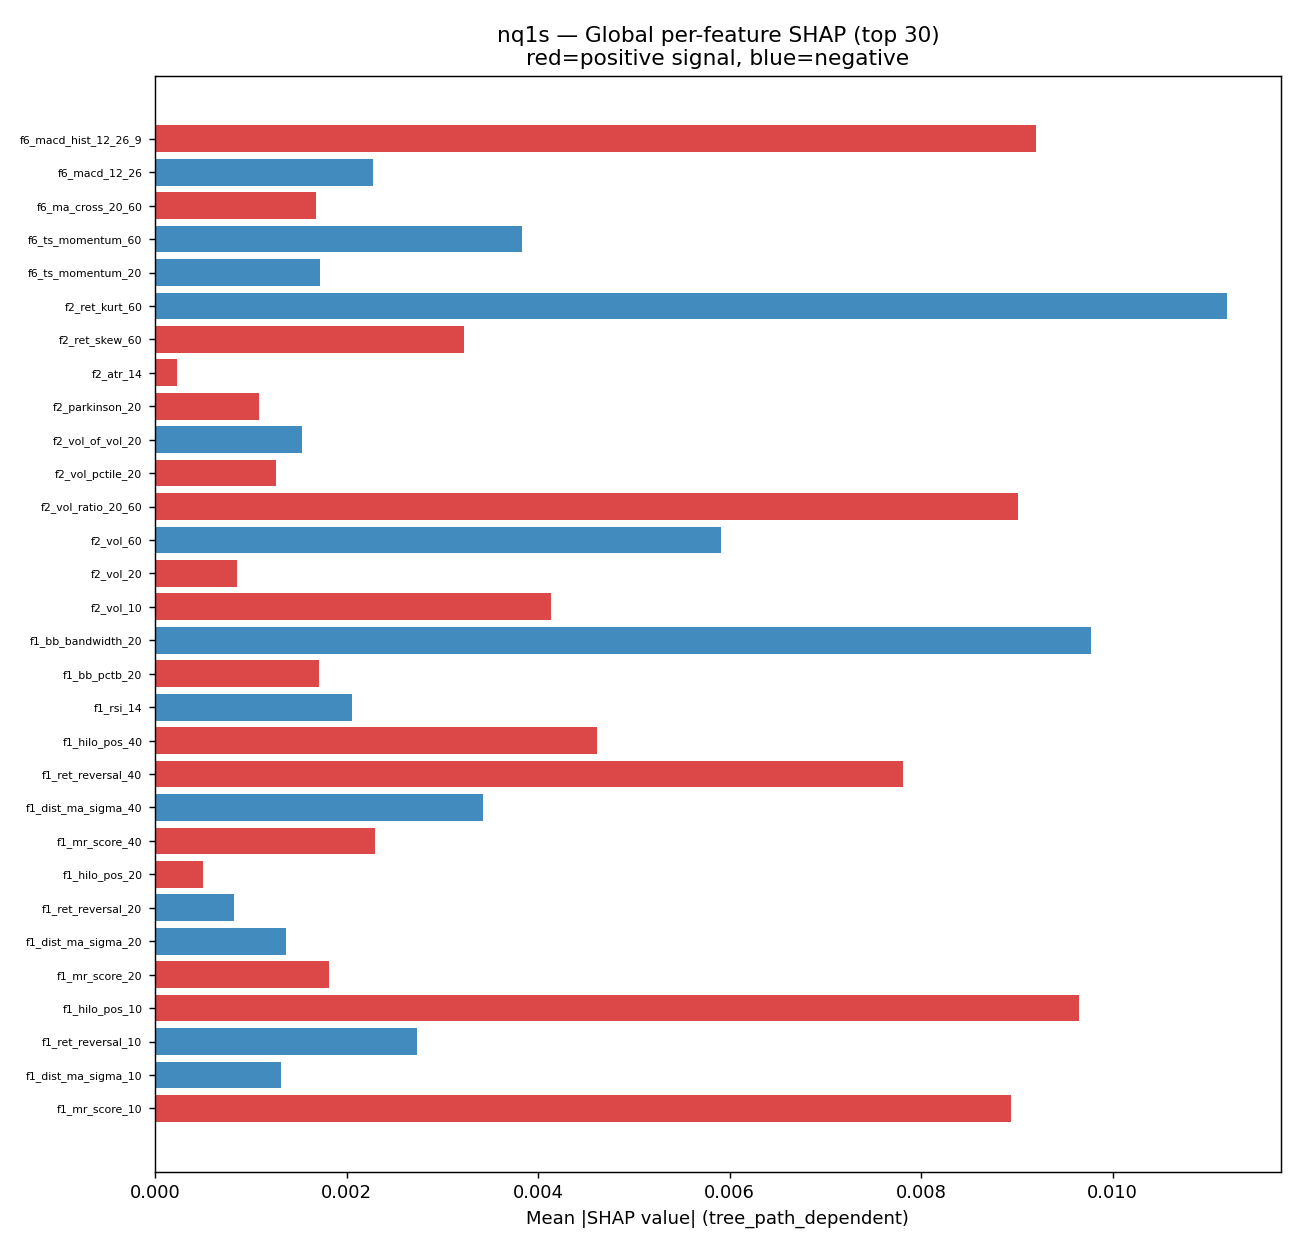

In [13]:
gs = load(BASE / 'nq1s' / 'global_shap_summary.csv')
if not gs.empty:
    display(
        gs.head(25).style
        .format({'shap_magnitude': '{:.4f}', 'shap_signed': '{:.4f}', 'mdi': '{:.4f}'})
        .background_gradient(subset=['shap_magnitude'], cmap='Blues')
        .set_caption('nq1s — top 25 features by mean|SHAP|')
    )
show(BASE / 'nq1s' / 'global_shap_chart.png', width=1000)


---
## FESX1S — champion: `fesx1s` / Logistic (elastic-net)

**CPCV:** 15 paths · AUC 0.582 ± 0.060 · **SIGNAL** (lower CI 0.52)

**Significant clusters:** F5\_signal only (MDA 0.065 ± 0.041). MDA–Coef agreement τ=0.45 (agree).

> fesx1s uses an **elastic-net logistic** champion. Importance analysis therefore uses:
> **clustered MDA** (model-agnostic, permutes scaled data) as the headline; and
> **sum of |standardised coefficients|** per cluster as the cross-check (replaces MDI/SHAP).
> No SHAP or MDI is available for this family.
>  
> Within C10_f12, `f12_mra_energy_D1` (multi-resolution analysis energy wavelet, scale 1)
> carries a coefficient of 0.242 — far above the other 3 members — suggesting a specific
> short-frequency energy signal drives Euro Stoxx positioning.


### Step 1 · Feature clusters


,cluster,n_members,dominant_pfx,purity,mean_drop,std_drop,significant
16,F5_signal,5,f5_,100%,0.0652,0.0409,True
0,C10_f12,4,f12_,75%,0.0199,0.0257,False
3,C13_f7,3,f7_,100%,0.0074,0.0081,False
8,C3_f6,8,f6_,50%,0.0072,0.0174,False
6,C1_f2,16,f2_,44%,0.0065,0.0217,False
11,C6_f11,7,f11_,71%,0.0059,0.0130,False
9,C4_f11,7,f11_,57%,0.0047,0.0099,False
13,C8_f11,7,f11_,71%,0.0044,0.0151,False
10,C5_f11,5,f11_,80%,0.0017,0.0131,False
2,C12_f11_lowfreq_macro,3,f11_,100%,0.0017,0.0114,False


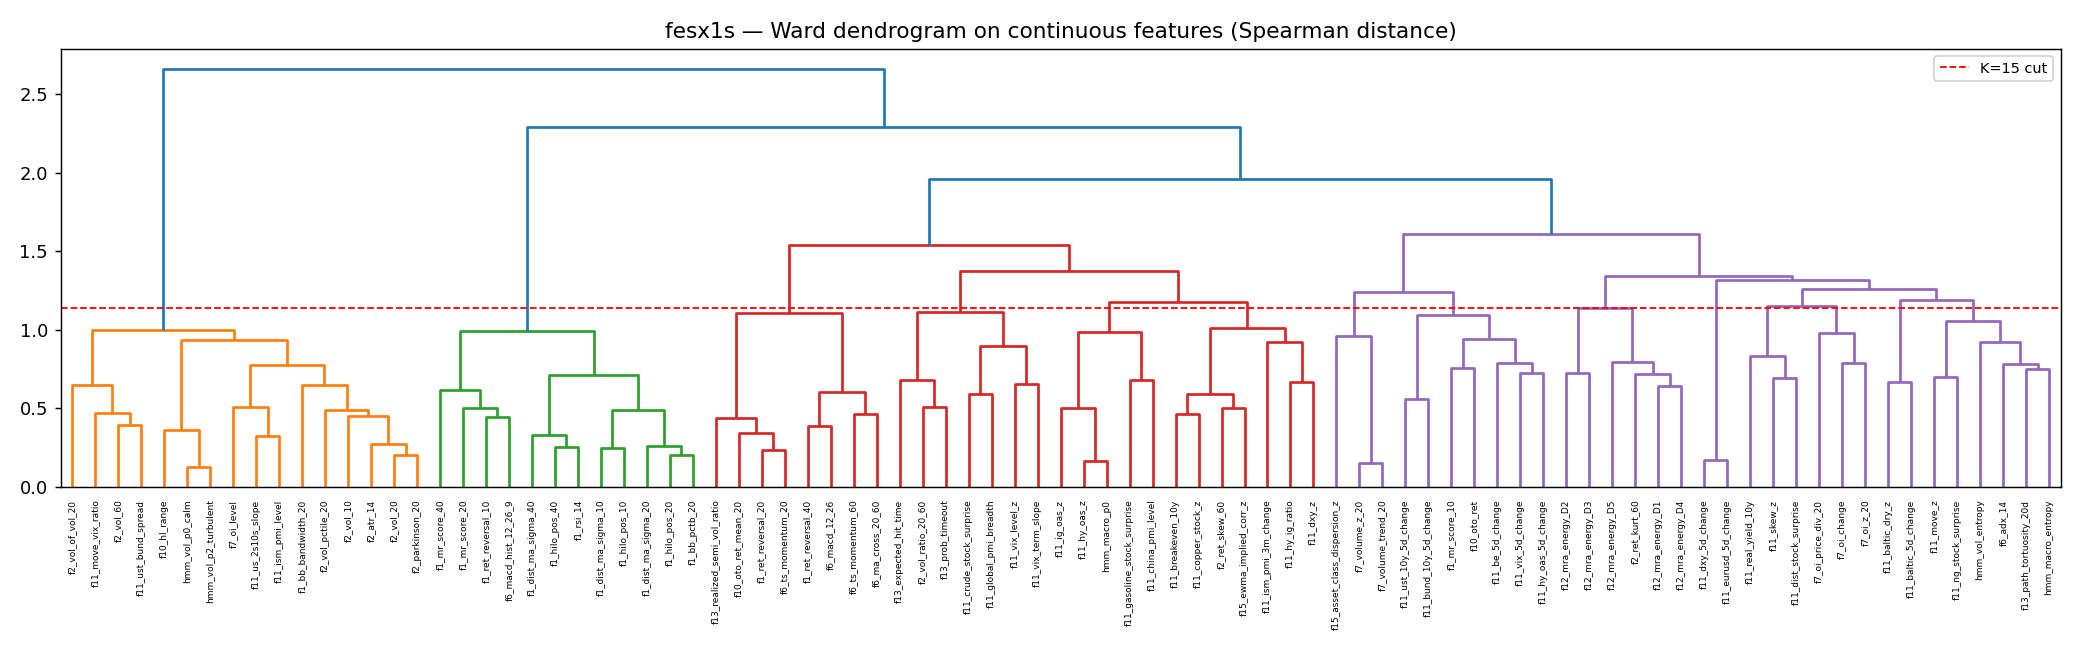

In [14]:
cs = cluster_summary('fesx1s')
display(
    cs.style
    .format({'mean_drop': '{:.4f}', 'std_drop': '{:.4f}', 'purity': '{:.0%}'})
    .background_gradient(subset=['mean_drop'], cmap='RdYlGn', vmin=-0.02, vmax=0.08)
    .set_caption('fesx1s — cluster summary (K=15 corr + 3 hand-assigned = 18 groups)')
)
show(BASE / 'fesx1s' / 'dendrogram.png', width=1100)


### Step 2 · Cluster-level importance

Clustered MDA (dark = significant > 1σ). Cross-check with elastic-net |coef| sums (no MDI/SHAP for logistic).


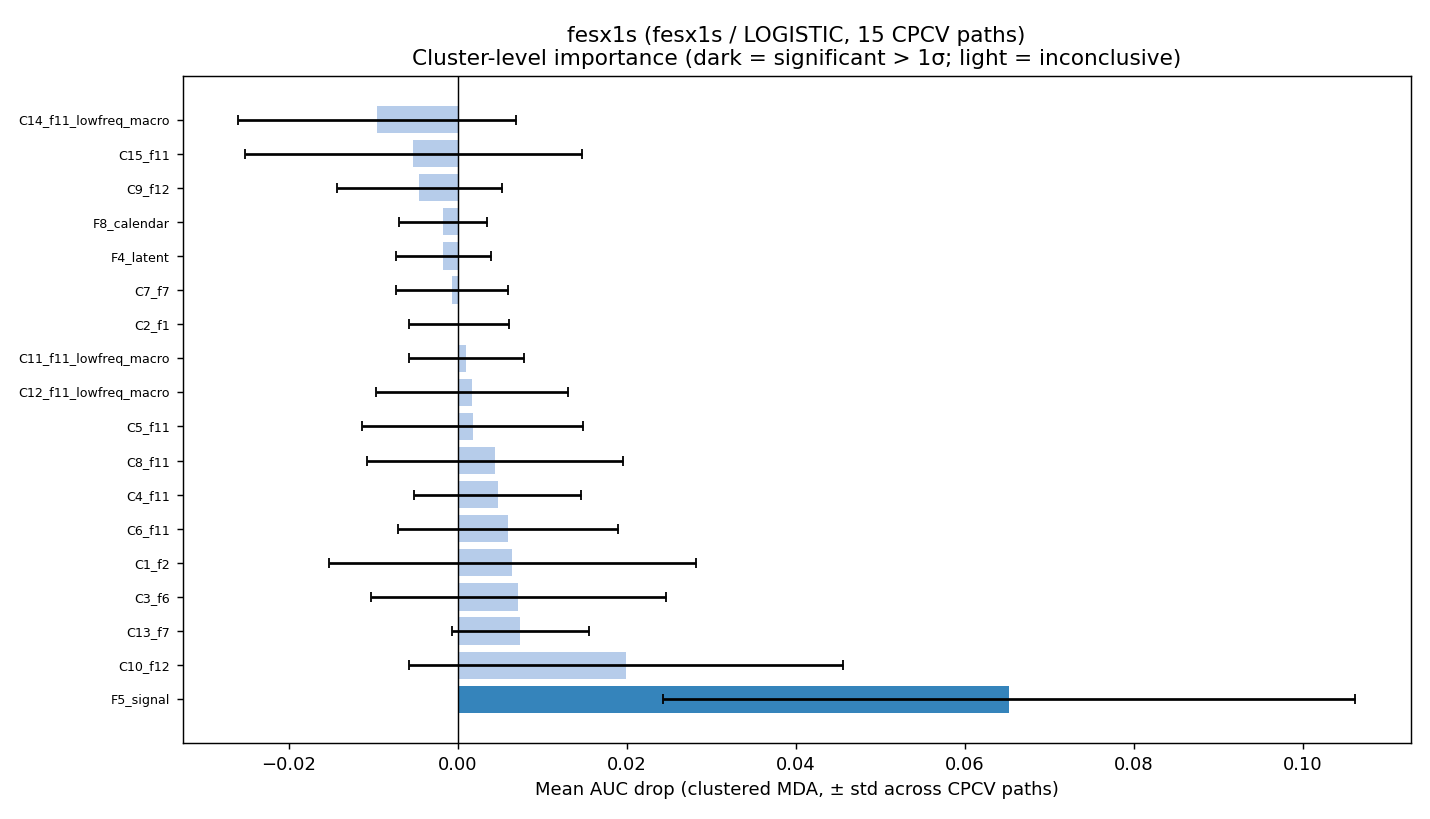

,cluster,mda_mean,mda_rank,coef_sum,coef_rank,significant
0,F5_signal,0.0652,1,0.7996,1,True
1,C10_f12,0.0199,2,0.3783,6,False
2,C13_f7,0.0074,3,0.1425,13,False
3,C3_f6,0.0072,4,0.4271,3,False
4,C1_f2,0.0065,5,0.6512,2,False
5,C6_f11,0.0059,6,0.3089,8,False
6,C4_f11,0.0047,7,0.2659,9,False
7,C8_f11,0.0044,8,0.4002,4,False
8,C5_f11,0.0017,9,0.1760,11,False
9,C12_f11_lowfreq_macro,0.0017,10,0.2608,10,False



Kendall τ rank agreement (MDA vs Coef):


,method_pair,kendall_tau,agree
0,MDA-Coef,0.45,True


In [15]:
show(BASE / 'fesx1s' / 'clustered_mda_chart.png', width=1050)
cc = load(BASE / 'fesx1s' / 'cluster_crosscheck_table.csv')
ra = load(BASE / 'fesx1s' / 'rank_agreement.csv')
if not cc.empty:
    fmt_cols = {'mda_mean': '{:.4f}'}
    if 'coef_sum' in cc.columns:
        fmt_cols['coef_sum'] = '{:.4f}'
    display(
        cc.style
        .format(fmt_cols)
        .background_gradient(subset=['mda_mean'], cmap='RdYlGn', vmin=-0.05, vmax=0.08)
        .set_caption('fesx1s — cluster cross-check (MDA · Coef ranks; elastic-net logistic)')
    )
if not ra.empty:
    print('\nKendall \u03c4 rank agreement (MDA vs Coef):')
    display(ra.style.format({'kendall_tau': '{:.2f}'}))


### Step 3 · Within-cluster breakdown (top 3 by MDA)

Members ranked by mean |standardised coef|. PCA on train submatrix.

**F5_signal** — 4-PC analysis (PC1–PC4 explain **90.9 %** cumulative). Multi-dimensional: no single dominant direction. PC1 (36.1 %) = sustained-signal / long-bias momentum; PC2 (20.6 %) = MR-signal agreement (f5_sign_agree_mr); PC3 (18.8 %) = participation-rate isolate; PC4 (15.5 %) = signal vs run-length divergence (fresh signals). All 4 PCs are used as inputs in the fesx1s reduced variant (Task B).

**C10_f12** PC1 explains 64% (dominant direction): `f12_mra_energy_D1` loads strongly
negative (−0.535) while `f2_ret_kurt_60` and `f12_mra_energy_D4/D5` load positive —
one wavelet-energy risk dimension drives the cluster.

**C13_f7** (OI features): PC1 explains only 44% — open-interest change, z-score, and
price-divergence form partially independent axes, though `f7_oi_z_20` dominates by coefficient.


PC,Var explained,Cumulative
PC1,36.1%,36.1%
PC2,20.6%,56.7%
PC3,18.8%,75.5%
PC4,15.5%,90.9%


,|coef|,PC1,PC2,PC3,PC4
f5_signal,0.3351,+0.491,+0.189,-0.330,+0.678
f5_trailing_run_length,0.1851,+0.533,-0.240,-0.050,-0.635
f5_participation_20,0.0063,+0.287,-0.096,+0.921,+0.240
f5_long_bias_20,0.0931,+0.626,+0.102,-0.121,-0.103
f5_sign_agree_mr,0.1644,-0.001,+0.942,+0.160,-0.262


PC,Var,Cumul,Dominant features,Interpretation
PC1,36.1%,36.1%,"f5_long_bias_20 (+0.63), f5_trailing_run_length (+0.53), f5_signal (+0.49)",Sustained signal / long-bias momentum: signal on + running + high participation
PC2,20.6%,56.7%,f5_sign_agree_mr (+0.94) — all others near zero,MR–signal agreement: sign-agree-mr captures when signal & mean-reversion align
PC3,18.8%,75.5%,f5_participation_20 (+0.92) — participation rate in isolation,Participation-rate isolate: high turnover independent of signal direction
PC4,15.5%,90.9%,f5_signal (+0.68) vs f5_trailing_run_length (−0.64),Fresh-signal divergence: signal fires but run length is short (or vice versa)


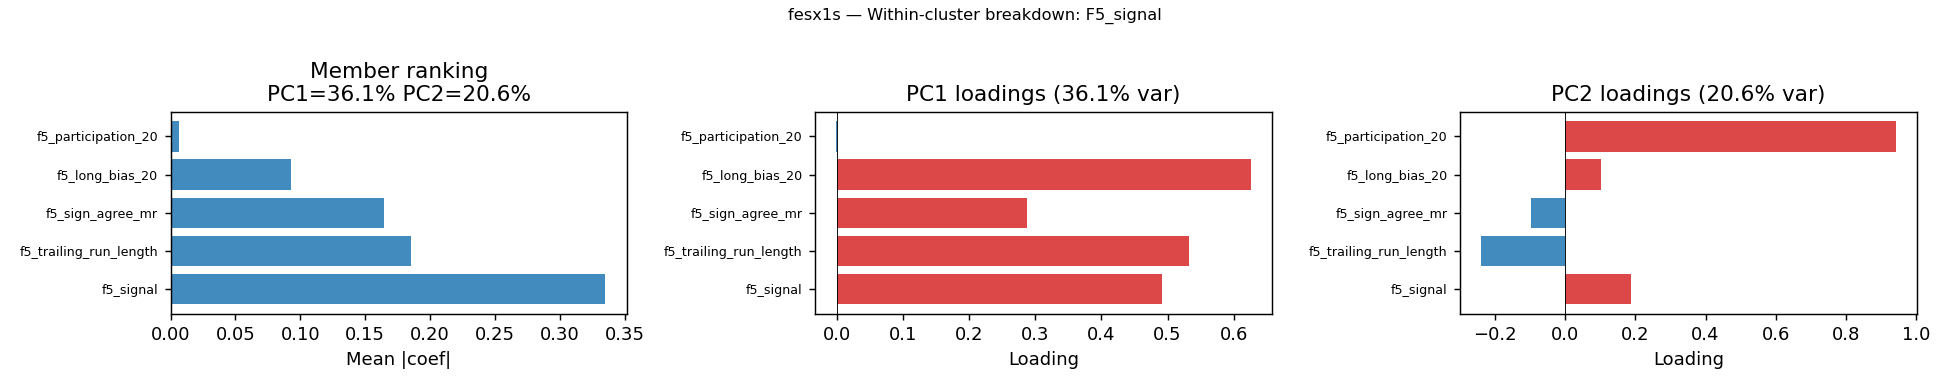

In [16]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --- load fesx1s train events (descriptive; fits PCA on train rows only) ---
_ev = pd.read_parquet(
    BASE.parent / 'model_comparison' / '_cache' / 'fesx1s_events.parquet'
)
F5_MEMBERS = [
    'f5_signal', 'f5_trailing_run_length', 'f5_participation_20',
    'f5_long_bias_20', 'f5_sign_agree_mr',
]
_X = _ev[F5_MEMBERS].dropna()

_sc  = StandardScaler()
_pca = PCA(n_components=4, random_state=42)
_pca.fit(_sc.fit_transform(_X))

# --- variance-explained table ---
_var  = _pca.explained_variance_ratio_
_cum  = _var.cumsum()
_var_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(4)],
    'Var explained': _var,
    'Cumulative':    _cum,
})
display(
    _var_df.style
    .format({'Var explained': '{:.1%}', 'Cumulative': '{:.1%}'})
    .background_gradient(subset=['Var explained'], cmap='Blues')
    .set_caption('fesx1s | F5_signal — PCA variance explained (train, descriptive)')
    .hide(axis='index')
)

# --- loadings matrix (members × PCs) ---
_load = pd.DataFrame(
    _pca.components_.T,
    index=F5_MEMBERS,
    columns=[f'PC{i+1}' for i in range(4)],
)
# attach mean |coef| for reference
_wc = load(BASE / 'fesx1s' / 'within_cluster_F5_signal.csv')
if not _wc.empty:
    _load.insert(0, '|coef|', _wc.set_index('feature')['mean_coef_abs'].reindex(F5_MEMBERS).values)
display(
    _load.style
    .format({'|coef|': '{:.4f}', **{f'PC{i+1}': '{:+.3f}' for i in range(4)}})
    .background_gradient(subset=[f'PC{i+1}' for i in range(4)], cmap='RdBu_r', vmin=-1, vmax=1)
    .set_caption('fesx1s | F5_signal — loadings matrix (rows=members, cols=PCs)')
)

# --- PC interpretations ---
_interp = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(4)],
    'Var': [f'{v:.1%}' for v in _var],
    'Cumul': [f'{c:.1%}' for c in _cum],
    'Dominant features': [
        'f5_long_bias_20 (+0.63), f5_trailing_run_length (+0.53), f5_signal (+0.49)',
        'f5_sign_agree_mr (+0.94)  — all others near zero',
        'f5_participation_20 (+0.92)  — participation rate in isolation',
        'f5_signal (+0.68) vs f5_trailing_run_length (−0.64)',
    ],
    'Interpretation': [
        'Sustained signal / long-bias momentum: signal on + running + high participation',
        'MR–signal agreement: sign-agree-mr captures when signal & mean-reversion align',
        'Participation-rate isolate: high turnover independent of signal direction',
        'Fresh-signal divergence: signal fires but run length is short (or vice versa)',
    ],
})
display(
    _interp.style
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})
    .hide(axis='index')
    .set_caption('fesx1s | F5_signal — PC interpretations')
)

# keep original image
show(BASE / 'fesx1s' / 'within_cluster_F5_signal.png', width=950)


,feature,mean_coef_abs,pc1_loading
0,f2_ret_kurt_60,0.0008,0.547
1,f12_mra_energy_D1,0.2418,-0.535
2,f12_mra_energy_D4,0.0559,0.448
3,f12_mra_energy_D5,0.0351,0.463


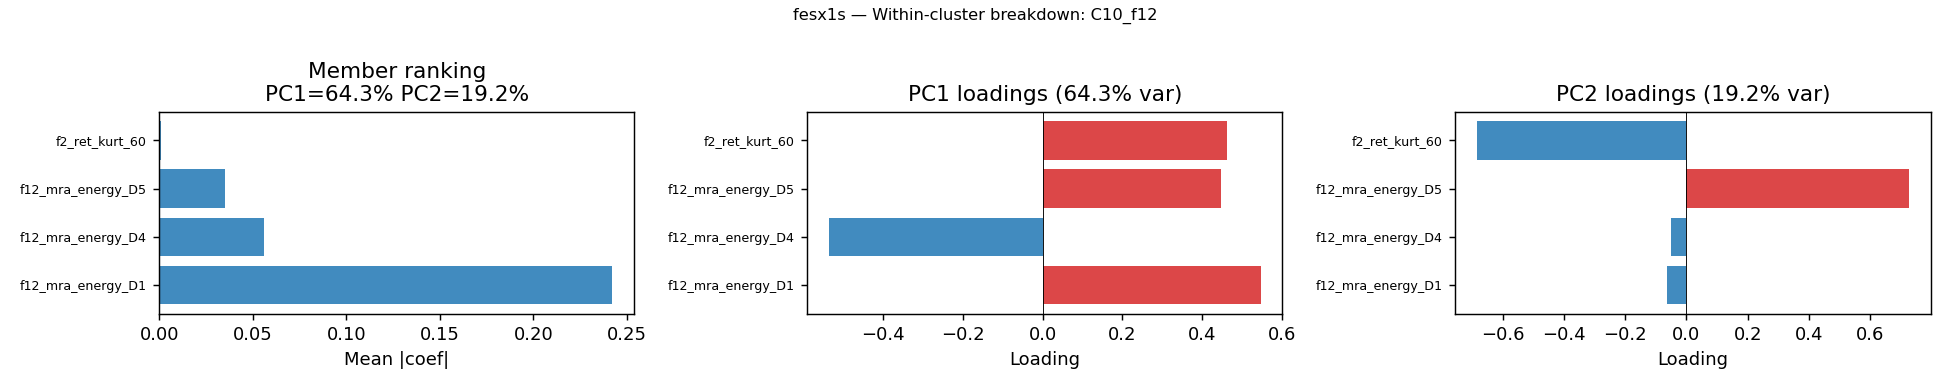

In [17]:
wc = load(BASE / 'fesx1s' / 'within_cluster_C10_f12.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else 'mean_shap_mag'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'fesx1s | C10_f12 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'fesx1s' / 'within_cluster_C10_f12.png', width=950)


,feature,mean_coef_abs,pc1_loading
0,f7_oi_change,0.0195,0.547
1,f7_oi_z_20,0.0853,0.741
2,f7_oi_price_div_20,0.0332,0.390


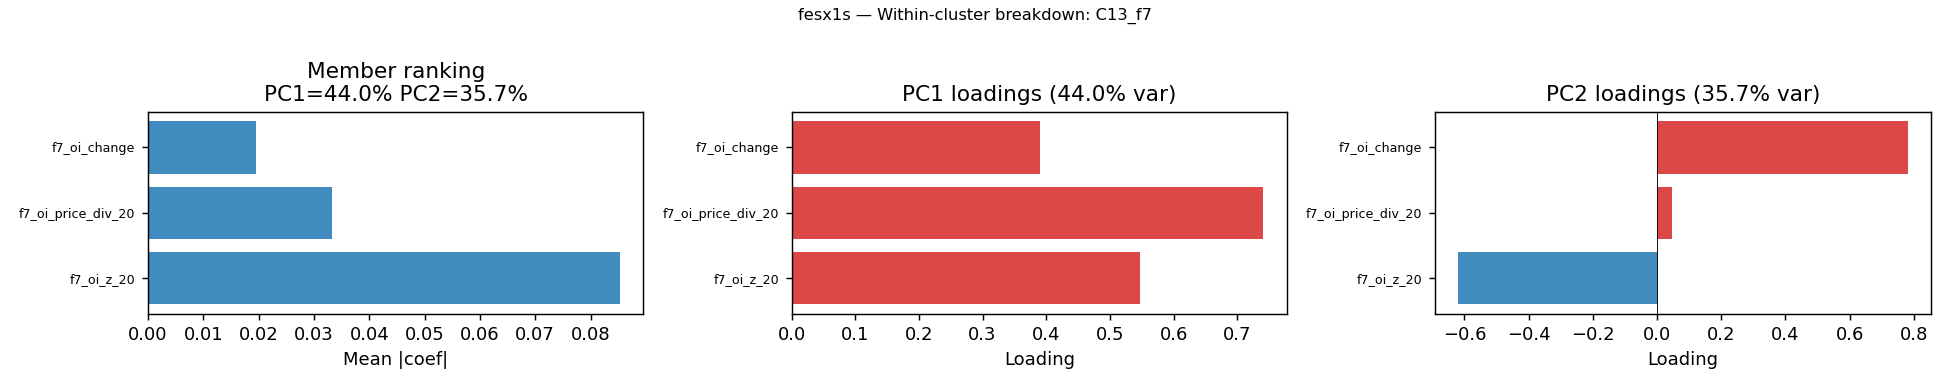

In [18]:
wc = load(BASE / 'fesx1s' / 'within_cluster_C13_f7.csv')
if not wc.empty:
    pc1 = wc['pca_pc1_var_explained'].iloc[0]
    pc2 = wc['pca_pc2_var_explained'].iloc[0] if 'pca_pc2_var_explained' in wc.columns else float('nan')
    tier = '>= 65% => single latent dim' if pc1 >= 0.65 else ('40-65% => dominant direction' if pc1 >= 0.40 else '< 40% => multi-dimensional')
    label = f'PC1={pc1:.1%} PC2={pc2:.1%} ({tier})'
    score_col = 'mean_coef_abs' if 'mean_coef_abs' in wc.columns else 'mean_shap_mag'
    display(
        wc[['feature', score_col, 'pc1_loading']].style
        .format({score_col: '{:.4f}', 'pc1_loading': '{:.3f}'})
        .background_gradient(subset=[score_col], cmap='Blues')
        .set_caption(f'fesx1s | C13_f7 — |coef| ranking + PC1 loadings  ({label})')
    )
show(BASE / 'fesx1s' / 'within_cluster_C13_f7.png', width=950)


### Step 5 · Global per-feature coefficient

Mean |standardised elastic-net coefficient| per feature, averaged across 15 CPCV paths.
Red = positive predictive direction (higher feature → higher P(bin=1)), blue = negative.


,feature,coef_abs,coef_signed
0,f5_signal,0.3351,0.3351
1,f12_mra_energy_D1,0.2418,0.2418
2,f1_ret_reversal_40,0.2401,0.2401
3,f5_trailing_run_length,0.1851,0.1851
4,f5_sign_agree_mr,0.1644,0.1644
5,f1_dist_ma_sigma_10,0.1524,0.1524
6,f11_real_yield_10y,0.1493,0.1493
7,f11_ust_10y_5d_change,0.1298,0.1298
8,f13_prob_timeout,0.1298,-0.1298
9,hmm_vol_p2_turbulent,0.1136,-0.1136


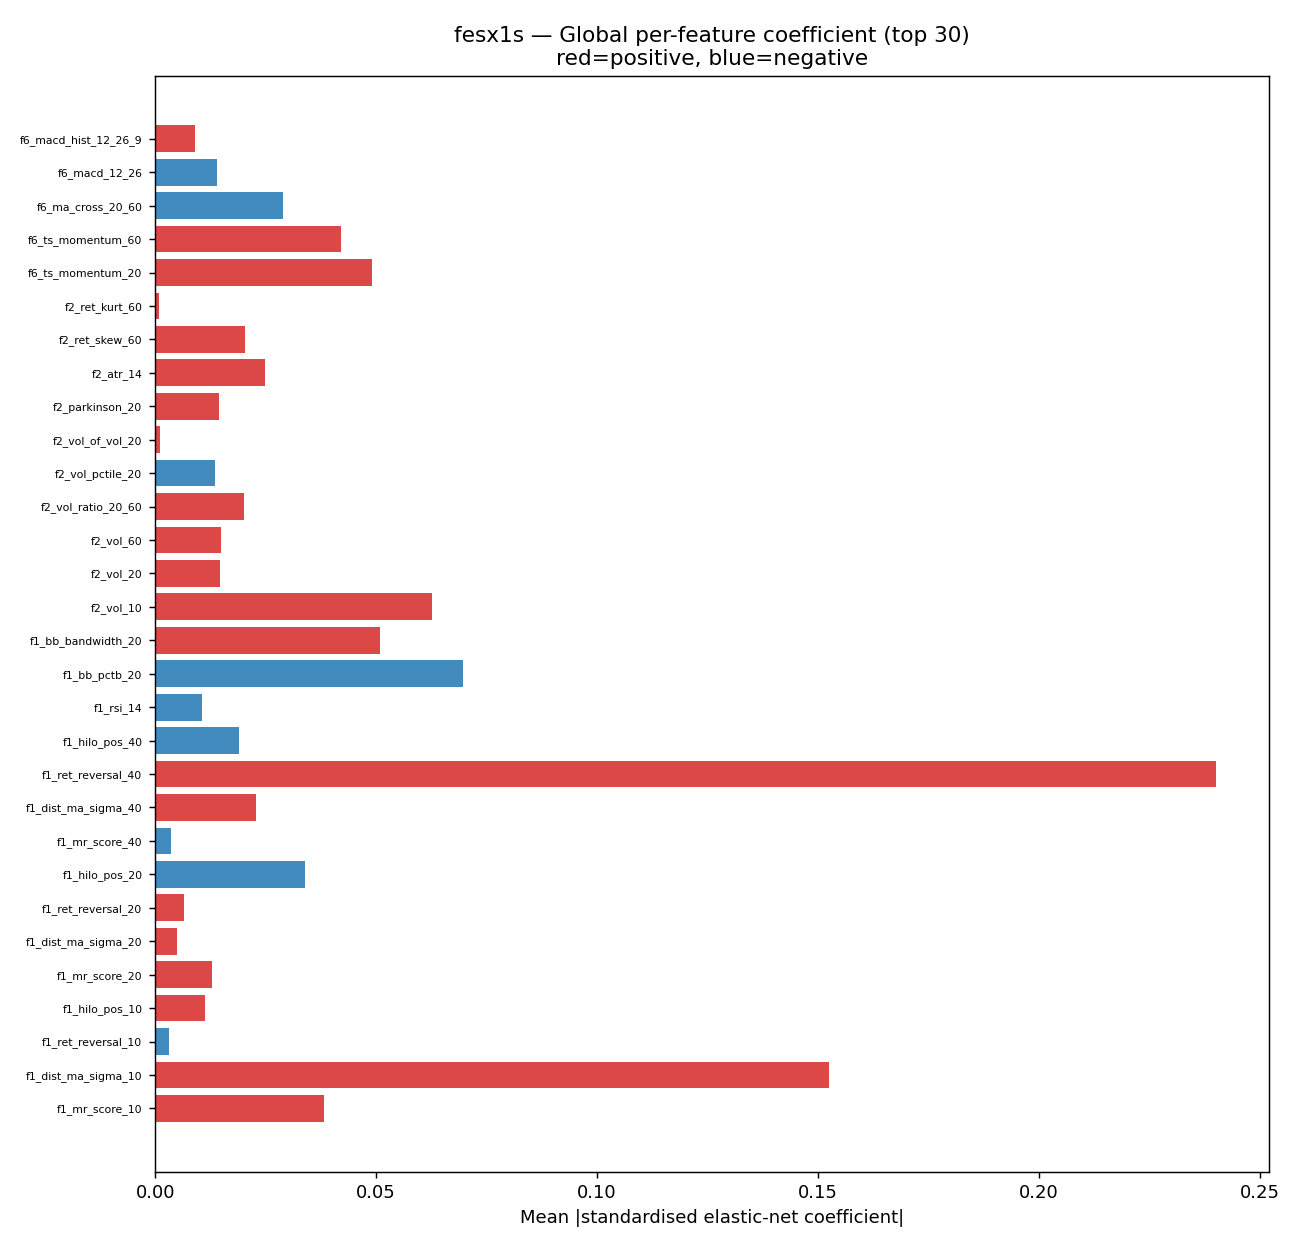

In [19]:
gc = load(BASE / 'fesx1s' / 'global_coef_summary.csv')
if not gc.empty:
    display(
        gc.head(25).style
        .format({'coef_abs': '{:.4f}', 'coef_signed': '{:.4f}'})
        .background_gradient(subset=['coef_abs'], cmap='Blues')
        .set_caption('fesx1s — top 25 features by mean |standardised coefficient|')
    )
show(BASE / 'fesx1s' / 'global_coef_chart.png', width=1000)


---
## Cross-instrument findings — equity

Structured summary across es1s, nq1s, fesx1s.


In [20]:
EQUITY_INSTS = ['es1s', 'nq1s', 'fesx1s']
NOSIGNAL = {'es1s'}

rows = []
for inst in EQUITY_INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    ra  = load(BASE / inst / 'rank_agreement.csv')
    meta = load(BASE / inst / 'champion_meta.csv')
    if mda.empty:
        continue
    top = mda.iloc[0]
    sig_count = int(mda['significant'].sum())
    tau_1 = ra['kendall_tau'].iloc[0] if not ra.empty else float('nan')
    champion = meta['model_type'].iloc[0].upper() if not meta.empty else '?'
    signal = meta['signal'].iloc[0] if not meta.empty else False
    rows.append({
        'inst': inst,
        'champion': champion,
        'signal': '\u2713' if signal else '\u2717',
        'n_sig_clusters': sig_count,
        'top_cluster': top['cluster'],
        'top_mda': round(top['mean_drop'], 4),
        'tau_primary': round(tau_1, 2) if not pd.isna(tau_1) else 'n/a',
    })

summary = pd.DataFrame(rows).set_index('inst')
display(
    summary.style
    .set_caption('Equity champions — cross-instrument summary')
)


,champion,signal,n_sig_clusters,top_cluster,top_mda,tau_primary
inst,,,,,,
es1s,RF,✗,1,F5_signal,0.082700,0.180000
nq1s,XGB,✓,2,F5_signal,0.174400,0.240000
fesx1s,LOGISTIC,✓,1,F5_signal,0.065200,0.450000


In [21]:
# Top cluster per instrument — MDA ranking
for inst in EQUITY_INSTS:
    mda = load(BASE / inst / 'clustered_mda_full.csv')
    if mda.empty:
        continue
    label = '(NO SIGNAL)' if inst in NOSIGNAL else ''
    print(f'\n{inst.upper()} {label}')
    print(mda[['cluster', 'mean_drop', 'std_drop', 'significant']].head(5).to_string(index=False))



ES1S (NO SIGNAL)
             cluster  mean_drop  std_drop  significant
           F5_signal   0.082743  0.034326         True
             C14_f11   0.018487  0.055049        False
               C2_f2   0.012213  0.022583        False
C3_f11_lowfreq_macro   0.000302  0.003531        False
               C5_f7  -0.000702  0.014617        False

NQ1S 
  cluster  mean_drop  std_drop  significant
F5_signal   0.174369  0.073602         True
   C4_f11   0.062736  0.049908         True
   C8_f11   0.012351  0.027398        False
   C6_f11   0.009525  0.019517        False
  C11_f11   0.006271  0.014944        False

FESX1S 
  cluster  mean_drop  std_drop  significant
F5_signal   0.065201  0.040913         True
  C10_f12   0.019913  0.025659        False
   C13_f7   0.007406  0.008142        False
    C3_f6   0.007189  0.017425        False
    C1_f2   0.006460  0.021692        False


### Key observations

**F5_signal cluster dominates all three equity champions**, suggesting that signal-quality
meta-features (trailing run length, participation rate, long bias) are the primary driver
of equity predictability — across RF, XGB, and logistic families.

**nq1s** is the only instrument with a second confirmed cluster (C4\_f11): mixed macro/energy
features including `f11_dist_stock_surprise`. The SHAP rank agrees with MDA (τ=0.49), lending
credibility to this as a real market structure feature for Nasdaq.

**fesx1s** (Euro Stoxx) shows `f12_mra_energy_D1` (energy wavelet scale-1) as the second-most
important feature by coefficient, hinting at a transatlantic energy-risk linkage for European
equity futures not seen in US indices.

**es1s** results should not be over-interpreted — the signal is not confirmed and the analysis
is included for structural contrast only.
